In [8]:
# Imports
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp
import jax
import jax.numpy as jnp
import numpy as np
#import scienceplots
import matplotlib.pyplot as plt
#plt.style.use(["science", "no-latex"])
from abc import ABC, abstractmethod
from enum import Enum
from typing import Optional
from scipy.interpolate import interp1d
from copy import deepcopy

In [9]:
# Generate Perturbation objects
class PerturbationStatus(Enum):
    """
    Document type of active perturbation.
    0 := Thruster fully operational
    1 := Thruster is stuck off
    2 := Thruster is stuck on
    3 := Thruster is experiencing a different failure (sampled from a GP)
    """

    OPERATIONAL = 0
    STUCK_OFF = 1
    STUCK_ON = 2
    SAMPLE_PERTURBATION = 3
    FAULTY_VALVE = 4


class Perturbation(ABC):
    """
    Base class for all perturbations applied to the model.
    Perturbations are defined as changes to the model's
    dynamics such as a mismatch between desired thrust versus
    actual thrust.
    """
    thruster_mask = None  # Class attribute, shared by all instances

    def __init__(self, model_config) -> None:
        # Extract the number of thrusters
        self.nu = 12

        # Thruster env_mask to document the operational status of thrusters
        if Perturbation.thruster_mask is None:  # Only initialize once
            Perturbation.thruster_mask = jnp.full(
                (1, self.nu), PerturbationStatus.OPERATIONAL.value
            )

        # PRNG key to select among the working thrusters
        self.thruster_rng_key = jax.random.PRNGKey(42)

    def get_perturbed_envs(
        self, proportion: float, perturbed_envs: Optional[jnp.ndarray] = None
    ) -> jnp.ndarray:
        """
        Return array with envs where a failure occurs. If proportion and num_envs are too low, no envs will be perturbed.
        """
        if isinstance(perturbed_envs, jnp.ndarray):
            return perturbed_envs

        else:
            fraction_perturbed_envs = jnp.clip(proportion, 0.0, 1.0)
            num_perturbed_envs = int(fraction_perturbed_envs * 1)
            operational_thruster_mask = jnp.any(
                Perturbation.thruster_mask == PerturbationStatus.OPERATIONAL.value,
                axis=1,
            )  # Only select envs that still have functioning thrusters
            operational_envs = jnp.where(operational_thruster_mask)[0]
            key = jax.random.PRNGKey(np.random.randint(0, 9999))  # No reproducability
            shuffled_indices = jax.random.permutation(key, operational_envs)
            return shuffled_indices[:num_perturbed_envs]

    def select_thrusters(
        self,
        perturbed_envs: jnp.ndarray,
        perturbed_thrusters: Optional[jnp.ndarray] = None,
    ) -> jnp.ndarray:
        """
        Return thruster indices to fail.
        """

        if isinstance(perturbed_thrusters, jnp.ndarray):
            return perturbed_thrusters

        else:
            jax.random.split(self.thruster_rng_key, perturbed_envs.shape[0])

            def random_operational_thruster(key, row, max_size=self.nu):
                # Get indices of operational thrusters (pad with -1 if not enough)
                operational_thrusters = jnp.where(
                    row == PerturbationStatus.OPERATIONAL.value,
                    size=max_size,
                    fill_value=-1,
                )[0]

                # Replace invalid (-1) indices with a large number so they won't be selected
                valid_mask = operational_thrusters != -1
                masked_indices = jnp.where(valid_mask, operational_thrusters, max_size)

                # Randomly select a valid index
                random_idx = jax.random.choice(
                    key, masked_indices, p=(valid_mask / valid_mask.sum())
                )

                return random_idx

            # Select the rows from the array
            selected_envs = Perturbation.thruster_mask[perturbed_envs]

            # Generate subkeys for each row
            subkeys = jax.random.split(
                self.thruster_rng_key, num=perturbed_envs.shape[0]
            )

            # Vectorized selection of random zero indices
            vec_random_operational_thruster = jax.vmap(
                random_operational_thruster, in_axes=(0, 0)
            )
            selected_thrusters = vec_random_operational_thruster(subkeys, selected_envs)

            return selected_thrusters

    @abstractmethod
    def apply(self, input: np.ndarray, timestamp: Optional[float] = None) -> np.ndarray:
        pass

    @abstractmethod
    def key_callback(self, keycode: Optional[int] = None) -> None:
        pass


# Create a Perturbation object
class FaultyValve(Perturbation):
    def __init__(self, model_config) -> None:
        super().__init__(model_config)

        self.failure_type = PerturbationStatus.FAULTY_VALVE
        self.start_times = jnp.zeros((1, self.nu))

        # Store interpolation functions for each thruster
        self.interpolations = [None] * self.nu

    def apply(
        self, input: np.ndarray, timestamp: Optional[float] = None
    ) -> jnp.ndarray:
        input = input.reshape(
            1, self.nu
        )  # Reshape to account for multiple envs

        # Do a elementwise AND operation
        faulty = jnp.logical_and(
            Perturbation.thruster_mask == self.failure_type,
            timestamp >= self.start_times,
        )

        # Apply interpolation only to the affected thrusters with active perturbations
        if jnp.any(faulty):
            # Gather input values for the affected thrusters
            affected_inputs = input[faulty]

            # Apply the respective interpolation functions
            interpolated_values = jnp.array(
                [
                    self.interpolations[i](affected_inputs[idx])
                    for idx, i in enumerate(jnp.where(faulty)[0])
                ]
            )

            # Update the input array with interpolated values
            input[faulty] = interpolated_values

        return input

    def register_perturbation(
        self,
        perturbed_envs: Optional[jnp.ndarray] = None,
        index: Optional[int] = None,
        start_time: Optional[float] = 0.0,
        x_data: np.ndarray = None,
        y_data: np.ndarray = None,
    ) -> None:
        """
        Register a perturbation and store the interpolation data.
        """
        if index is not None:
            thruster_index = index
        else:
            # If we must choose the same thruster for all envs, some must be overridden
            thruster_index = np.random.randint(8)

        gp_perturbed_envs = self.get_perturbed_envs(1.0, perturbed_envs)

        Perturbation.thruster_mask = Perturbation.thruster_mask.at[
            gp_perturbed_envs, jnp.full(gp_perturbed_envs.shape[0], thruster_index)
        ].set(PerturbationStatus.FAULTY_VALVE.value)
        self.start_times = self.start_times.at[
            gp_perturbed_envs, jnp.full(gp_perturbed_envs.shape[0], thruster_index)
        ].set(start_time)

        # Create the interpolation function for the affected thruster
        self.interpolations[thruster_index] = interp1d(
            x_data, y_data, kind='linear', fill_value="extrapolate"
        )

        print(
            f"Thruster(s) affected by a faulty valve starting at {start_time} seconds."
        )

    def key_callback(self, keycode: Optional[int] = None) -> None:
        pass

In [10]:
# Custom class to define GP models for different failure types
class ThrusterFailureGPModel(gpflow.models.GPR):
    def __init__(
        self,
        train_x,
        train_y,
        kernel_type="RBF",
        lengthscale=0.2,
        outputscale=1.0,
    ):
        train_x = tf.convert_to_tensor(train_x, dtype=tf.float64)
        train_x_reshaped = tf.reshape(train_x, [-1, 1])
        train_y = tf.convert_to_tensor(train_y, dtype=tf.float64)
        train_y_reshaped = tf.reshape(train_y, [-1, 1])
        
        kernel = self._choose_kernel(kernel_type, lengthscale, outputscale)
        # kernel.variance.assign(outputscale)

        mean_function = gpflow.mean_functions.Constant()

        super().__init__((train_x_reshaped, train_y_reshaped), kernel=kernel, mean_function=mean_function)

    def _choose_kernel(self, kernel_type, lengthscale, outputscale):
        if kernel_type == "RBF":
            return gpflow.kernels.SquaredExponential(lengthscales=lengthscale, variance=outputscale)
        elif kernel_type == "Matern":
            return gpflow.kernels.Matern32(lengthscales=lengthscale, variance=outputscale)
        raise ValueError(f"Unsupported kernel type: {kernel_type}")

    def forward(self, x):
        test_x = jnp.atleast_2d(x).T if x.ndim == 1 else x
        test_x = tf.convert_to_tensor(x, dtype=tf.float64)
        
        mean_x, covar_x = self.predict_f(tf.reshape(test_x, [-1,1]), full_cov=True)
        scale = tf.linalg.cholesky(covar_x[0, :, :])

        return tfp.distributions.MultivariateNormalTriL(
            loc=mean_x[:, 0], scale_tril=scale
        )

In [11]:
## Function to generate data for different failure modes
def generate_failure_data(failure_type, num_points=100, valve_min=0.1, valve_max=0.5, upper_bound = 0.6):
    demanded_force = np.linspace(0, upper_bound, num_points)  # Values between 0 and 1
    valve_max = 0.8 * upper_bound

    key = jax.random.PRNGKey(42)

    if failure_type == "Saturated Thrust":
        # Close to y=x from 0 to 0.5, then converge to ~0.5 after that
        actual_force = np.where(demanded_force < 0.3 * upper_bound, 
                                   demanded_force, 
                                   0.3 * upper_bound + 0.1 * jax.random.normal(key, shape=demanded_force.shape) * (upper_bound - demanded_force))
    
    elif failure_type == "Faulty Valve":
        # Define thresholds
        lower_threshold = 0.67 * upper_bound
        upper_threshold = 0.73 * upper_bound

        # Piecewise linear: min value at lower_threshold, linear up to max value at upper_threshold
        actual_force = np.zeros_like(demanded_force) + valve_min
        
        # Linear region between lower_threshold and upper_threshold
        linear_region = (demanded_force >= lower_threshold) & (demanded_force <= upper_threshold)
        actual_force[linear_region] = valve_min + ((demanded_force[linear_region] - lower_threshold) / 
                                                   (upper_threshold - lower_threshold)) * (valve_max - valve_min)
        
        # Max value for demanded_force > upper_threshold
        actual_force[demanded_force > upper_threshold] = valve_max
    
    elif failure_type == "Thrust Instability":
        # Oscillations in thrust due to instability
        actual_force = demanded_force - 0.1 * upper_bound * jnp.sin(10 * demanded_force) + 0.05 * upper_bound * jax.random.normal(key, shape=demanded_force.shape)
    
    elif failure_type == "thermal_stress":
        # At high demanded forces, actual force decreases due to heat
        actual_force = demanded_force

    else:
        raise ValueError(f"Unknown failure type: {failure_type}")
    
    actual_force = jax.lax.clamp(0.0, actual_force, upper_bound)  # Ensure the values stay between 0 and 1
    return demanded_force, actual_force

# Function to sample from the GP
def sample_gp_function(gp_model, demanded_force, num_samples=3):
    
    observed_pred = gp_model.forward(demanded_force)
    
    samples = observed_pred.sample(num_samples)
    return samples

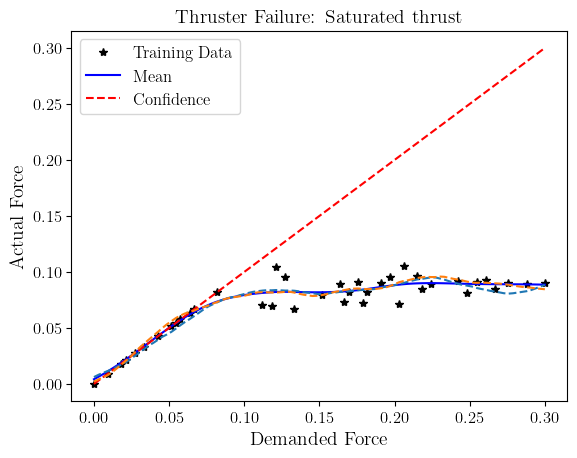

Thruster(s) affected by a faulty valve starting at 5.0 seconds.
Thruster(s) affected by a faulty valve starting at 6.0 seconds.


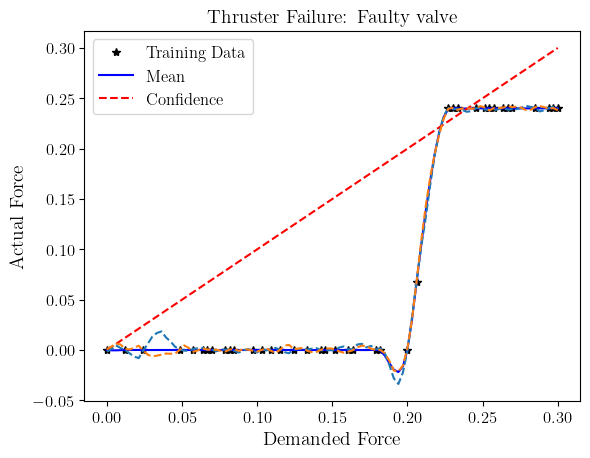

Thruster(s) affected by a faulty valve starting at 5.0 seconds.
Thruster(s) affected by a faulty valve starting at 6.0 seconds.


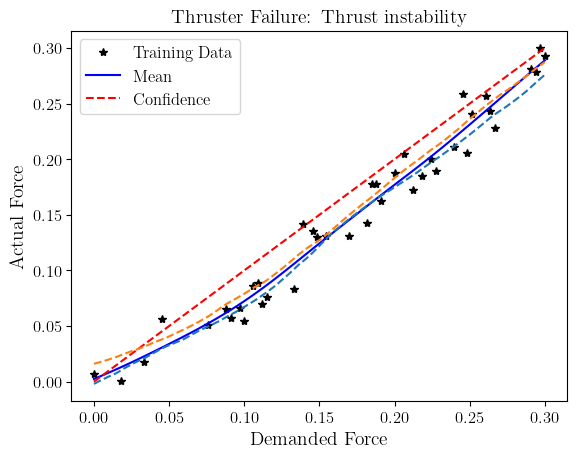

Thruster(s) affected by a faulty valve starting at 5.0 seconds.
Thruster(s) affected by a faulty valve starting at 6.0 seconds.


2024-10-23 13:00:30.438708: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2024-10-23 13:00:30.472489: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


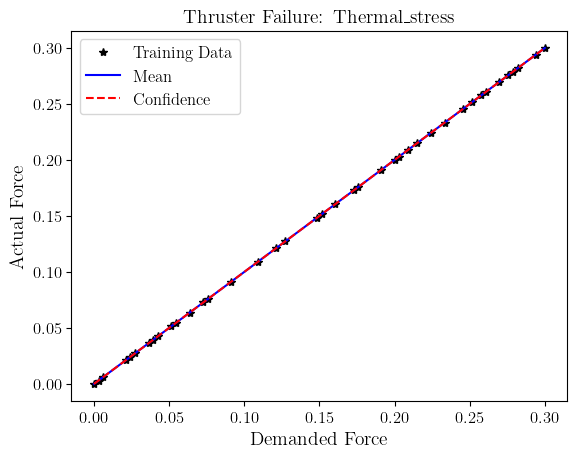

Thruster(s) affected by a faulty valve starting at 5.0 seconds.
Thruster(s) affected by a faulty valve starting at 6.0 seconds.


Text(0, 0.5, 'Actual Force')

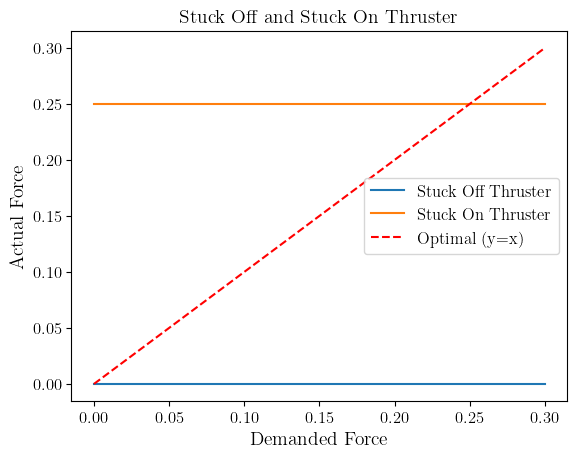

In [12]:
# Main function to create and plot the GPs for the failure models

# Set up the likelihood and training data for different failures
failure_modes = {
    "Saturated Thrust": {
        "kernel": "Matern",
        "valve_min": None,
        "valve_max": None,
        "lengthscale": 0.1,
        "outputscale": 0.1,
    },
    "Faulty Valve": {
        "kernel": "Matern",
        "valve_min": 0.0,
        "valve_max": 0.3,
        "lengthscale": 0.3,
        "outputscale": 0.4,
    },
    "Thrust Instability": {
        "kernel": "Matern",
        "valve_min": None,
        "valve_max": None,
        "lengthscale": 0.15,
        "outputscale": 0.5,
    },
    "thermal_stress": {
        "kernel": "Matern",
        "valve_min": None,
        "valve_max": None,
        "lengthscale": 0.15,
        "outputscale": 0.5,
    },
}

num_points = 100
num_samples = 2
subset_size = 40  # Choose how many points you want in the subset

upper_bound = 0.3
x_test = jnp.linspace(0, upper_bound, 100)

for failure_type, params in failure_modes.items():
    demanded_force, actual_force = generate_failure_data(
        failure_type,
        num_points=num_points,
        valve_min=params.get("valve_min", 0.1),
        valve_max=params.get("valve_max", 0.8),
        upper_bound=upper_bound
    )

    # Chose a subset of point pairs
    indices = np.random.choice(
        range(1, num_points - 1), size=subset_size - 2, replace=False
    )  # Exclude first and last points
    indices = np.concatenate(
        ([0], indices, [num_points - 1])
    )  # Include first and last points
    indices = np.sort(indices)

    # Use the selected indices to get the subset of points
    demanded_force_subset = demanded_force[indices]
    actual_force_subset = actual_force[indices]

    # Initialize likelihood and model with the specified kernel and set hyperparameters directly
    model = ThrusterFailureGPModel(
        demanded_force_subset,
        actual_force_subset,
        kernel_type=params["kernel"],
        lengthscale=params["lengthscale"],
        outputscale=params["outputscale"],
    )
    opt = gpflow.optimizers.Scipy()
    opt.minimize(model.training_loss, model.trainable_variables)

    # No training; we set the hyperparameters manually

    # Plot the GP and sampled functions
    observed_pred = model.forward(x_test)
    lower = observed_pred.loc - 1.96 * np.sqrt(tf.linalg.tensor_diag_part(observed_pred.scale_tril))
    upper = observed_pred.loc + 1.96 * np.sqrt(tf.linalg.tensor_diag_part(observed_pred.scale_tril))

    # Plotting
    plt.figure()
    plt.plot(demanded_force_subset, actual_force_subset, "k*")
    plt.plot(x_test, observed_pred.loc, "b")
    # plt.fill_between(x_test, lower, upper, alpha=0.5)
    plt.plot(
        demanded_force_subset, demanded_force_subset, "r--"
    )  # Plot y=x for optimal mapping
    plt.title(f"Thruster Failure: {failure_type.capitalize()}")
    plt.legend(["Training Data", "Mean", "Confidence", "Optimal (y=x)"])
    plt.xlabel("Demanded Force")
    plt.ylabel("Actual Force")

    # Sample from the GP and plot the sampled functions
    sampled_functions = sample_gp_function(
        model, x_test, num_samples=num_samples
    )
    for i in range(num_samples):
        plt.plot(x_test, sampled_functions[i], "--")

    plt.show()

    test = FaultyValve(None)
    test.register_perturbation(index=2, start_time=5.0, x_data=x_test, y_data=sampled_functions[0])
    test.register_perturbation(index=3, start_time=6.0, x_data=x_test, y_data=sampled_functions[1])

    # input = np.random.rand(12)
    # print(input)

    # input_perturbed = test.apply(input, timestamp=5.1)
    # print(input_perturbed)

    # #######################

    # input = np.random.rand(12)
    # print(input)

    # input_perturbed = test.apply(input, timestamp=6.1)
    # print(input_perturbed)

    # print("Test")

# Plot stuck off and stuck on
plt.figure()
plt.plot(x_test, np.zeros_like(x_test), "-", label="Stuck Off Thruster")
plt.plot(x_test, 0.25 * np.ones_like(x_test), "-", label="Stuck On Thruster")
plt.plot(
    demanded_force_subset, demanded_force_subset, "r--"
)  # Plot y=x for optimal mapping
plt.title(f"Stuck Off and Stuck On Thruster")
plt.legend(["Stuck Off Thruster", "Stuck On Thruster", "Optimal (y=x)"])
plt.xlabel("Demanded Force")
plt.ylabel("Actual Force")

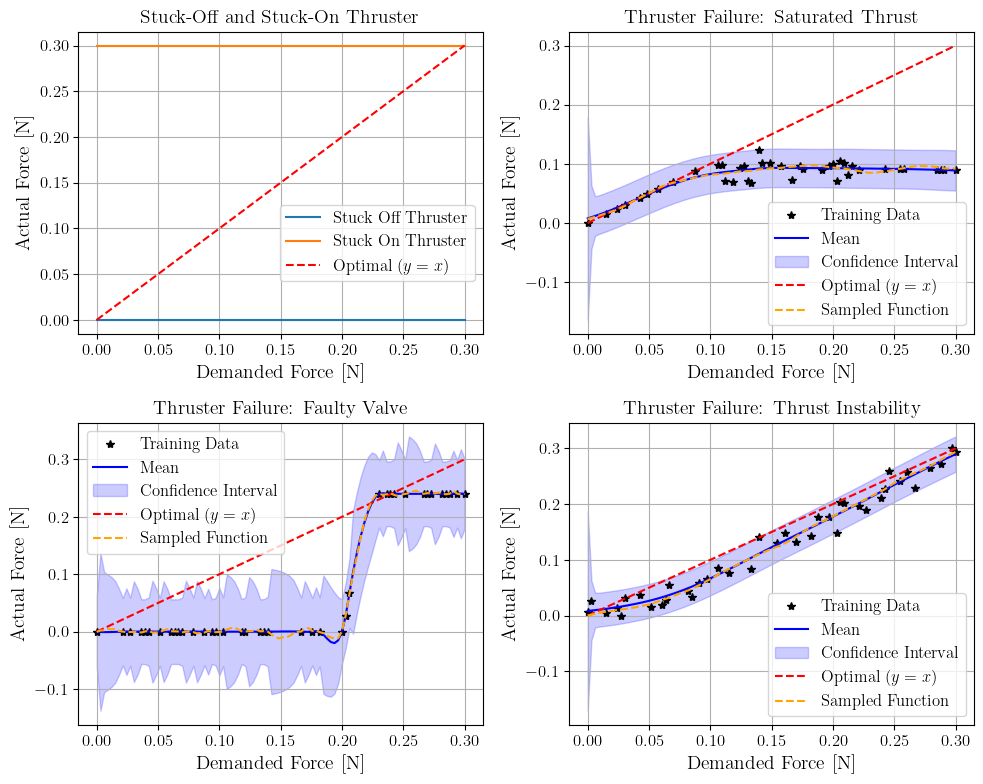

In [13]:
import matplotlib as mpl

# Use LaTeX for rendering text in plots
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12  # Adjust as needed
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

# Create a 2x2 subplot with adjusted figure size
fig, axs = plt.subplots(2, 2, figsize=(10, 8))  # Adjusted figsize for better fit

# Prepare x_test for plotting
x_test = np.linspace(0, upper_bound, 100)

### Plot 1: Stuck Off and Stuck On Thruster ###
axs[0, 0].plot(x_test, np.zeros_like(x_test), "-", label="Stuck Off Thruster")
axs[0, 0].plot(x_test, 0.3 * np.ones_like(x_test), "-", label="Stuck On Thruster")
axs[0, 0].plot(x_test, x_test, "r--", label="Optimal ($y=x$)")
axs[0, 0].set_title("Stuck-Off and Stuck-On Thruster")
axs[0, 0].legend(loc='center right', bbox_to_anchor=(1.0, 0.3))
axs[0, 0].set_xlabel("Demanded Force [N]")
axs[0, 0].set_ylabel("Actual Force [N]")
axs[0, 0].grid(True)

### Plot 2: Saturated Thrust ###
failure_type = "Saturated Thrust"
params = failure_modes[failure_type]
demanded_force, actual_force = generate_failure_data(
    failure_type,
    num_points=num_points,
    valve_min=params.get("valve_min", 0.1),
    valve_max=params.get("valve_max", 0.8),
    upper_bound=upper_bound
)
indices = np.random.choice(range(1, num_points - 1), size=subset_size - 2, replace=False)
indices = np.concatenate(([0], indices, [num_points - 1]))
indices = np.sort(indices)
demanded_force_subset = demanded_force[indices]
actual_force_subset = actual_force[indices]

model = ThrusterFailureGPModel(
    demanded_force_subset,
    actual_force_subset,
    kernel_type=params["kernel"],
    lengthscale=params["lengthscale"],
    outputscale=params["outputscale"],
)
opt = gpflow.optimizers.Scipy()
opt.minimize(model.training_loss, model.trainable_variables)

observed_pred = model.forward(x_test)
lower = observed_pred.loc - 1.96 * np.sqrt(tf.linalg.tensor_diag_part(observed_pred.scale_tril))
upper = observed_pred.loc + 1.96 * np.sqrt(tf.linalg.tensor_diag_part(observed_pred.scale_tril))

# Sample from the GP and plot the sampled functions
sampled_functions = sample_gp_function(
    model, x_test, num_samples=num_samples
)

axs[0, 1].plot(demanded_force_subset, actual_force_subset, "k*", markersize=6, label="Training Data")
axs[0, 1].plot(x_test, observed_pred.loc, "b", linewidth=1.5, label="Mean")
axs[0, 1].fill_between(x_test, lower, upper, color='blue', alpha=0.2, label="Confidence Interval")
axs[0, 1].plot(x_test, x_test, "r--", label="Optimal ($y=x$)")
axs[0, 1].plot(x_test, sampled_functions[0], "--", color='orange', label="Sampled Function")
axs[0, 1].set_title(f"Thruster Failure: {failure_type}")
axs[0, 1].legend(loc='best')
axs[0, 1].set_xlabel("Demanded Force [N]")
axs[0, 1].set_ylabel("Actual Force [N]")
axs[0, 1].grid(True)

### Plot 3: Faulty Valve ###
failure_type = "Faulty Valve"
params = failure_modes[failure_type]
demanded_force, actual_force = generate_failure_data(
    failure_type,
    num_points=num_points,
    valve_min=params.get("valve_min", 0.1),
    valve_max=params.get("valve_max", 0.8),
    upper_bound=upper_bound
)
indices = np.random.choice(range(1, num_points - 1), size=subset_size - 2, replace=False)
indices = np.concatenate(([0], indices, [num_points - 1]))
indices = np.sort(indices)
demanded_force_subset = demanded_force[indices]
actual_force_subset = actual_force[indices]

model = ThrusterFailureGPModel(
    demanded_force_subset,
    actual_force_subset,
    kernel_type=params["kernel"],
    lengthscale=params["lengthscale"],
    outputscale=params["outputscale"],
)
opt = gpflow.optimizers.Scipy()
opt.minimize(model.training_loss, model.trainable_variables)

observed_pred = model.forward(x_test)
lower = observed_pred.loc - 1.96 * np.sqrt(tf.linalg.tensor_diag_part(observed_pred.scale_tril))
upper = observed_pred.loc + 1.96 * np.sqrt(tf.linalg.tensor_diag_part(observed_pred.scale_tril))

# Sample from the GP and plot the sampled functions
sampled_functions = sample_gp_function(
    model, x_test, num_samples=num_samples
)

axs[1, 0].plot(demanded_force_subset, actual_force_subset, "k*", markersize=6, label="Training Data")
axs[1, 0].plot(x_test, observed_pred.loc, "b", linewidth=1.5, label="Mean")
axs[1, 0].fill_between(x_test, lower, upper, color='blue', alpha=0.2, label="Confidence Interval")
axs[1, 0].plot(x_test, x_test, "r--", label="Optimal ($y=x$)")
axs[1, 0].plot(x_test, sampled_functions[0], "--", color='orange', label="Sampled Function")
axs[1, 0].set_title(f"Thruster Failure: {failure_type}")
axs[1, 0].legend(loc='best')
axs[1, 0].set_xlabel("Demanded Force [N]")
axs[1, 0].set_ylabel("Actual Force [N]")
axs[1, 0].grid(True)

### Plot 4: Thrust Instability ###
failure_type = "Thrust Instability"
params = failure_modes[failure_type]
demanded_force, actual_force = generate_failure_data(
    failure_type,
    num_points=num_points,
    valve_min=params.get("valve_min", 0.1),
    valve_max=params.get("valve_max", 0.8),
    upper_bound=upper_bound
)
indices = np.random.choice(range(1, num_points - 1), size=subset_size - 2, replace=False)
indices = np.concatenate(([0], indices, [num_points - 1]))
indices = np.sort(indices)
demanded_force_subset = demanded_force[indices]
actual_force_subset = actual_force[indices]

model = ThrusterFailureGPModel(
    demanded_force_subset,
    actual_force_subset,
    kernel_type=params["kernel"],
    lengthscale=params["lengthscale"],
    outputscale=params["outputscale"],
)
opt = gpflow.optimizers.Scipy()
opt.minimize(model.training_loss, model.trainable_variables)

observed_pred = model.forward(x_test)
lower = observed_pred.loc - 1.96 * np.sqrt(tf.linalg.tensor_diag_part(observed_pred.scale_tril))
upper = observed_pred.loc + 1.96 * np.sqrt(tf.linalg.tensor_diag_part(observed_pred.scale_tril))

# Sample from the GP and plot the sampled functions
sampled_functions = sample_gp_function(
    model, x_test, num_samples=num_samples
)

axs[1, 1].plot(demanded_force_subset, actual_force_subset, "k*", markersize=6, label="Training Data")
axs[1, 1].plot(x_test, observed_pred.loc, "b", linewidth=1.5, label="Mean")
axs[1, 1].fill_between(x_test, lower, upper, color='blue', alpha=0.2, label="Confidence Interval")
axs[1, 1].plot(x_test, x_test, "r--", label="Optimal ($y=x$)")
axs[1, 1].plot(x_test, sampled_functions[0], "--", color='orange', label="Sampled Function")
axs[1, 1].set_title(f"Thruster Failure: {failure_type}")
axs[1, 1].legend(loc='best')
axs[1, 1].set_xlabel("Demanded Force [N]")
axs[1, 1].set_ylabel("Actual Force [N]")
axs[1, 1].grid(True)

# Adjust layout
plt.tight_layout()

# Save the figure as a high-resolution PDF
plt.savefig('thruster_failures_gpflow.pdf', format='pdf', bbox_inches='tight', dpi=300)


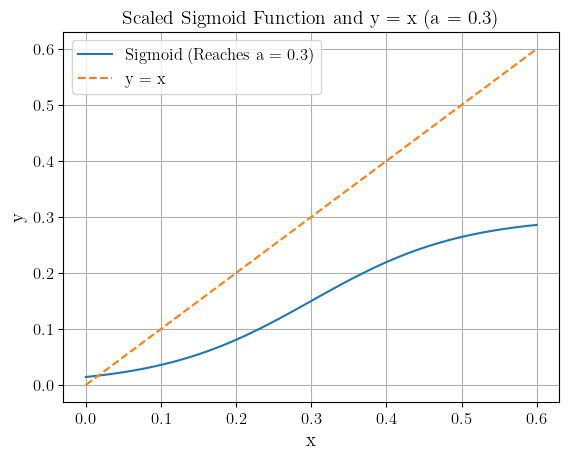

In [14]:
def scaled_sigmoid_torch(x, a=0.3):
    # Custom sigmoid function that is 0 at x=0 and reaches 'a' at x=0.6
    y = a / (1 + np.exp(-10 * (x - 0.3)))
    return y

# Define x range between 0 and 0.6
x = np.linspace(0, 0.6, 100)

# Set the target value 'a' at x=0.6
a_value = 0.3  # Change this to your desired value
y_sigmoid = scaled_sigmoid_torch(x, a=a_value)

# Plot y = x line
y_linear = x

# Convert to numpy for plotting
x_np = x
y_sigmoid_np = y_sigmoid
y_linear_np = y_linear

# Plot the sigmoid function and y = x line
plt.plot(x_np, y_sigmoid_np, label=f'Sigmoid (Reaches a = {a_value})')
plt.plot(x_np, y_linear_np, label='y = x', linestyle='--')

# Add labels and legend
plt.title(f'Scaled Sigmoid Function and y = x (a = {a_value})')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()